## Importing libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##  Reading the fies

In [34]:
df = pd.read_csv(r'D:\GitHub\Data-Science\datasets\50_startup.csv')

In [35]:
df.head(10)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [36]:
df.info

<bound method DataFrame.info of     R&D Spend  Administration  Marketing Spend       State     Profit
0   165349.20       136897.80        471784.10    New York  192261.83
1   162597.70       151377.59        443898.53  California  191792.06
2   153441.51       101145.55        407934.54     Florida  191050.39
3   144372.41       118671.85        383199.62    New York  182901.99
4   142107.34        91391.77        366168.42     Florida  166187.94
5   131876.90        99814.71        362861.36    New York  156991.12
6   134615.46       147198.87        127716.82  California  156122.51
7   130298.13       145530.06        323876.68     Florida  155752.60
8   120542.52       148718.95        311613.29    New York  152211.77
9   123334.88       108679.17        304981.62  California  149759.96
10  101913.08       110594.11        229160.95     Florida  146121.95
11  100671.96        91790.61        249744.55  California  144259.40
12   93863.75       127320.38        249839.44     Florida

In [37]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


## Divide data into dependent and independents 

In [38]:
# x = df.drop('Profit').values
# y = df['Profit'].values


x = df.iloc[:,: -1].values
y = df.iloc[:,-1].values

## Feature Encoding - OneHotEncoder

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [40]:
ct = ColumnTransformer(transformers=[('cat',OneHotEncoder(),[3])], remainder ='passthrough')

In [41]:
X = np.array(ct.fit_transform(x))

In [46]:
y

array([192261.83, 191792.06, 191050.39, 182901.99, 166187.94, 156991.12,
       156122.51, 155752.6 , 152211.77, 149759.96, 146121.95, 144259.4 ,
       141585.52, 134307.35, 132602.65, 129917.04, 126992.93, 125370.37,
       124266.9 , 122776.86, 118474.03, 111313.02, 110352.25, 108733.99,
       108552.04, 107404.34, 105733.54, 105008.31, 103282.38, 101004.64,
        99937.59,  97483.56,  97427.84,  96778.92,  96712.8 ,  96479.51,
        90708.19,  89949.14,  81229.06,  81005.76,  78239.91,  77798.83,
        71498.49,  69758.98,  65200.33,  64926.08,  49490.75,  42559.73,
        35673.41,  14681.4 ])

## Train and Test Split

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2 )

In [48]:
len(X_train)

40

In [49]:
len(X_test)

10

In [50]:
X_test

array([[0.0, 1.0, 0.0, 101913.08, 110594.11, 229160.95],
       [0.0, 1.0, 0.0, 119943.24, 156547.42, 256512.92],
       [0.0, 0.0, 1.0, 77044.01, 99281.34, 140574.81],
       [0.0, 0.0, 1.0, 86419.7, 153514.11, 0.0],
       [0.0, 1.0, 0.0, 28663.76, 127056.21, 201126.82],
       [0.0, 0.0, 1.0, 94657.16, 145077.58, 282574.31],
       [0.0, 1.0, 0.0, 91749.16, 114175.79, 294919.57],
       [0.0, 1.0, 0.0, 153441.51, 101145.55, 407934.54],
       [0.0, 0.0, 1.0, 20229.59, 65947.93, 185265.1],
       [1.0, 0.0, 0.0, 78013.11, 121597.55, 264346.06]], dtype=object)

In [60]:
y_test

array([146121.95, 132602.65, 108552.04, 122776.86,  90708.19, 125370.37,
       124266.9 , 191050.39,  81229.06, 126992.93])

## Feature Scaling

In [51]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [52]:
X_test

array([[-0.81649658,  1.62368828, -0.69388867,  0.66308556, -0.39986355,
         0.17540969],
       [-0.81649658,  1.62368828, -0.69388867,  1.04796693,  1.23882766,
         0.39408838],
       [-0.81649658, -0.61588176,  1.44115338,  0.13221718, -0.80327599,
        -0.53283549],
       [-0.81649658, -0.61588176,  1.44115338,  0.33235564,  1.13066008,
        -1.65672949],
       [-0.81649658,  1.62368828, -0.69388867, -0.90053334,  0.18717356,
        -0.04872286],
       [-0.81649658, -0.61588176,  1.44115338,  0.50819684,  0.82981412,
         0.60244889],
       [-0.81649658,  1.62368828, -0.69388867,  0.44612112, -0.27214114,
         0.7011491 ],
       [-0.81649658,  1.62368828, -0.69388867,  1.7630388 , -0.73679842,
         1.6047025 ],
       [-0.81649658, -0.61588176,  1.44115338, -1.08057361, -1.99194263,
        -0.17553713],
       [ 1.22474487, -0.61588176, -0.69388867,  0.1529041 , -0.0074818 ,
         0.45671424]])

## Create Model

In [53]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predictions

In [54]:
y_pred = regressor.predict(X_test)

## Plotting of y_test vs y_pred

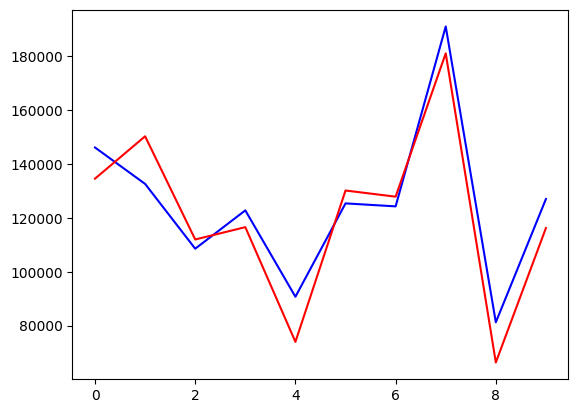

In [55]:
plt.plot(y_test, color ='blue', label='test')
plt.plot(y_pred, color ='red',label='predication')
plt.show()

## Out of the Predications

In [56]:
data = [[1.0,0.0,0.0,80000,125000,250000]]

new_df = pd.DataFrame(data)

In [57]:
new_df = sc.transform(new_df)

In [58]:
new_df

array([[ 1.22474487, -0.61588176, -0.69388867,  0.19531731,  0.11384929,
         0.34201765]])

In [59]:
single = regressor.predict(new_df)
single

array([117515.59164539])